# Mood Space Interpolation Demo

This notebook demonstrates how to:
1. Train a Mood Space compression model on two images
2. Interpolate between the images using the trained model
3. Visualize the interpolation results

The demo uses Jimi Hendrix images to show smooth transitions between portrait and action poses.

In [1]:
# Import required libraries
import torch
from PIL import Image
import numpy as np
import skdim

import sys
from app import train_mood_space, perform_two_image_interpolation

## Load and Prepare Images

Load the two Jimi Hendrix images and resize them to a consistent size for processing.

Loaded images: (512, 512) and (512, 512)
Input Images:


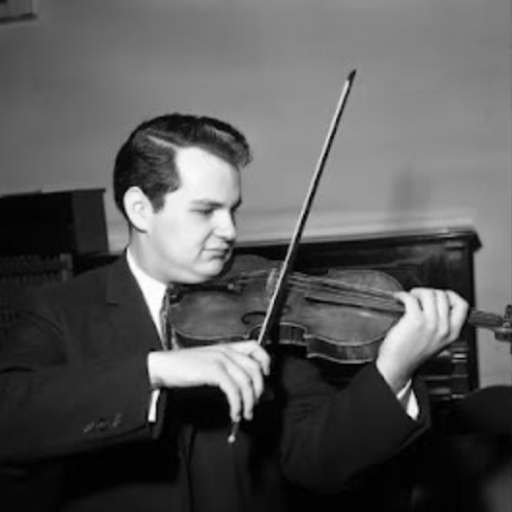

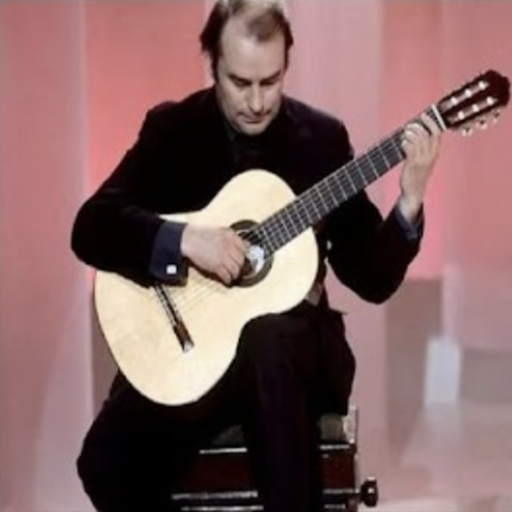

In [ ]:
# Load and prepare input images
path1 = "./images/easy_vs_hard.png"
path2 = "./images/easy_vs_hard/easy1b.png"

# Resize images to consistent size
image1 = Image.open(path1).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")
image2 = Image.open(path2).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")

print(f"Loaded images: {image1.size} and {image2.size}")

# Display the input images
print("Input Images:")
display(image1)
display(image2)

## Train Mood Space Model

Train a neural compression model that learns to compress the image features while preserving semantic relationships.

In [ ]:
# Train the Mood Space compression model
print("Training Mood Space model...")
model, trainer = train_mood_space(
    pil_images=[image1, image2], 
    learning_rate=0.001, 
    training_steps=1000,
    mlp_width=512,
    mlp_layers=2
)

print("Training completed!")

Training Mood Space model...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Training completed!


## Generate Interpolation

Create a smooth interpolation between the two images using the trained model.

In [5]:
# Define interpolation weights (0.0 = image1, 1.0 = image2)
interpolation_weights = np.linspace(0.0, 1.0, 11).tolist()
print(f"Interpolation weights: {interpolation_weights}")

# Generate interpolated images
print("Generating interpolated images...")
interpolated_images = perform_two_image_interpolation(
    image1=image1, 
    image2=image2, 
    model=model, 
    interpolation_weights=interpolation_weights,
    n_clusters=20, 
    match_method='hungarian',
    use_dino_matching=True
)

print(f"Generated {len(interpolated_images)} interpolated images")

Interpolation weights: [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Generating interpolated images...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generated 11 interpolated images


## Visualization Utilities

Helper function to create image grids for visualization.

In [6]:
def create_image_grid(images, rows, cols):
    """
    Create a grid layout of images.
    
    Args:
        images: List of PIL Images
        rows: Number of rows in the grid
        cols: Number of columns in the grid
    
    Returns:
        PIL.Image: Grid image
    """
    assert len(images) == rows * cols, f"Expected {rows*cols} images, got {len(images)}"

    # Get dimensions from first image
    width, height = images[0].size
    
    # Create empty grid canvas
    grid = Image.new('RGB', size=(cols * width, rows * height))
    
    # Paste each image into the grid
    for i, img in enumerate(images):
        x_pos = (i % cols) * width
        y_pos = (i // cols) * height
        grid.paste(img, box=(x_pos, y_pos))
    
    return grid

## Display Results

Show the complete interpolation sequence from the first image to the second image.

Creating grid with 13 images...

Interpolation Results:


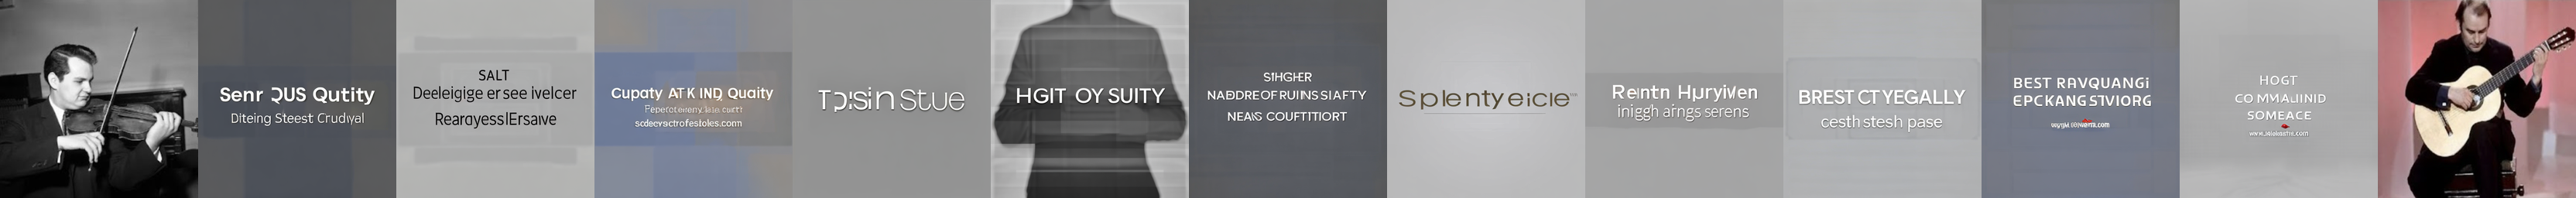

In [7]:
# Combine original images with interpolated results
all_images = [image1] + interpolated_images + [image2]

# Resize images for better display
display_size = (256, 256)
resized_images = [img.resize(display_size, Image.Resampling.LANCZOS) for img in all_images]

# Create and display the grid
print(f"Creating grid with {len(all_images)} images...")
result_grid = create_image_grid(resized_images, 1, len(resized_images))

print("\nInterpolation Results:")
display(result_grid)